# Experiment 4.0.3 — Hierarchical Fixed250 Multi-Spike SNN

Analysis only. Training is performed by the Slurm jobs under `scripts/bash_script/SNN_Bash/`. All models receive exactly the same scaled Fixed250 vectors; no sub-bin timing is reconstructed.

Primary question: does `Local128 -> RSNN128` outperform both the reused 1-layer RSNN128 Multi-HO baseline and the nearly parameter-matched RSNN176 control? The endpoint-state Linear probe is diagnostic only and sees one causal endpoint membrane vector, not temporal phases.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
root = repo_root / 'notebooks' / 'artifacts' / 'experiment_4_0_3_hierarchical_snn' / 'fixed250_hierarchical_multispike_v1'
runs_path = root / 'runs.csv'
summary_path = root / 'summary.csv'
effects_path = root / 'paired_effects.csv'
refs_path = root / 'references.csv'

if not runs_path.exists():
    raise FileNotFoundError(f'Finalized Exp4.0.3 artifacts not found: {runs_path}')

runs = pd.read_csv(runs_path)
summary = pd.read_csv(summary_path)
effects = pd.read_csv(effects_path)
refs = pd.read_csv(refs_path)
summary

,condition,valid_count_balanced_accuracy_mean,valid_count_balanced_accuracy_std,valid_count_macro_f1_mean,valid_count_macro_f1_std,state_probe_balanced_accuracy_mean,state_probe_balanced_accuracy_std,state_probe_macro_f1_mean,state_probe_macro_f1_std,state_tail_event_fraction_mean,state_tail_event_fraction_std,output_tail_event_fraction_mean,output_tail_event_fraction_std
0,local128_ff128,0.413385,0.029717,0.399552,0.034226,0.156278,0.064075,0.150767,0.060485,0.000001,0.000002,0.002017,0.000180
1,local128_rsnn128,0.443374,0.037392,0.436334,0.039570,0.481645,0.030683,0.475277,0.028129,0.768377,0.011388,0.776531,0.036790
2,rsnn128_multispike_reused,0.407640,0.025049,0.395307,0.023457,0.462232,0.056854,0.454803,0.058165,0.815376,0.014253,0.789115,0.024714
3,rsnn128_rsnn128,0.394346,0.016691,0.375135,0.026810,0.439306,0.030382,0.429677,0.029731,0.751850,0.004951,0.775059,0.018819
4,rsnn176_capacity,0.416121,0.038366,0.395495,0.042881,0.446462,0.058034,0.438374,0.055045,0.815441,0.013387,0.800333,0.013192


In [3]:
test = runs[runs['split'] == 'test'].copy()
order = [
    'rsnn128_multispike_reused',
    'rsnn176_capacity',
    'local128_ff128',
    'rsnn128_rsnn128',
    'local128_rsnn128',
]
table = (
    test.groupby('condition')[['valid_count_balanced_accuracy', 'state_probe_balanced_accuracy']]
    .agg(['mean', 'std'])
    .reindex(order)
)
table

valid_count_balanced_accuracy            \
                                                   mean       std   
condition                                                           
rsnn128_multispike_reused                      0.407640  0.025049   
rsnn176_capacity                               0.416121  0.038366   
local128_ff128                                 0.413385  0.029717   
rsnn128_rsnn128                                0.394346  0.016691   
local128_rsnn128                               0.443374  0.037392   

                          state_probe_balanced_accuracy            
                                                   mean       std  
condition                                                          
rsnn128_multispike_reused                      0.462232  0.056854  
rsnn176_capacity                               0.446462  0.058034  
local128_ff128                                 0.156278  0.064075  
rsnn128_rsnn128                                0.439306  0.030382  
local128_rsnn128                               0.481645  0.030683

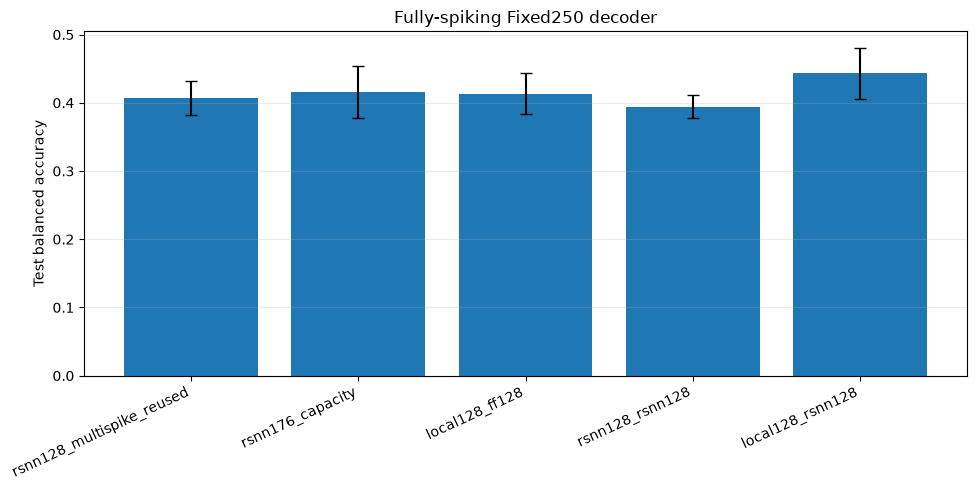

In [4]:
plot_data = test.groupby('condition')['valid_count_balanced_accuracy'].agg(['mean', 'std']).reindex(order)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(plot_data)), plot_data['mean'], yerr=plot_data['std'], capsize=4)
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels(plot_data.index, rotation=25, ha='right')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Fully-spiking Fixed250 decoder')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

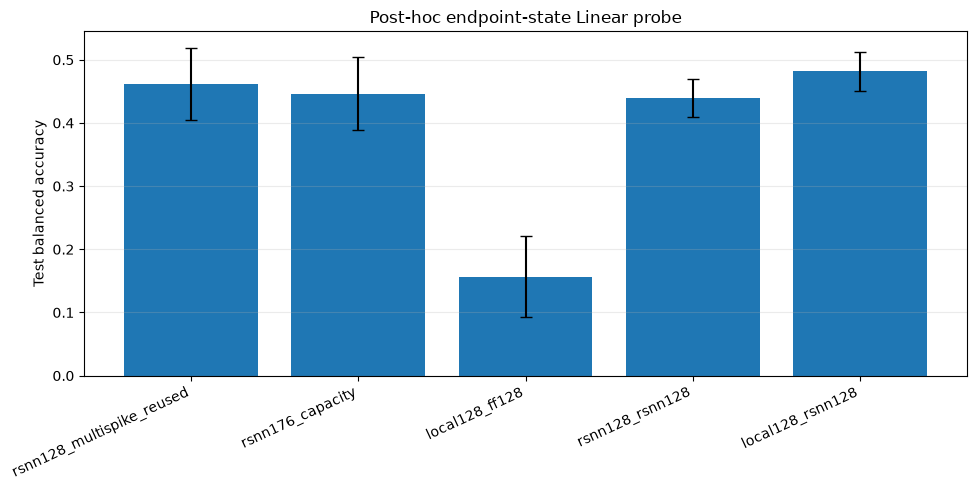

In [5]:
probe_data = test.groupby('condition')['state_probe_balanced_accuracy'].agg(['mean', 'std']).reindex(order)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(probe_data)), probe_data['mean'], yerr=probe_data['std'], capsize=4)
ax.set_xticks(range(len(probe_data)))
ax.set_xticklabels(probe_data.index, rotation=25, ha='right')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Post-hoc endpoint-state Linear probe')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [6]:
display(effects.groupby('condition')[['fully_spiking_delta_vs_baseline', 'state_probe_delta_vs_baseline']].agg(['mean', 'std']))
display(refs)

fully_spiking_delta_vs_baseline            \
                                            mean       std   
condition                                                    
local128_ff128                          0.005745  0.032710   
local128_rsnn128                        0.035734  0.042717   
rsnn128_rsnn128                        -0.013294  0.032505   
rsnn176_capacity                        0.008481  0.031755   

                 state_probe_delta_vs_baseline            
                                          mean       std  
condition                                                 
local128_ff128                       -0.305954  0.095157  
local128_rsnn128                      0.019413  0.067915  
rsnn128_rsnn128                      -0.022926  0.053996  
rsnn176_capacity                     -0.015770  0.053988

,reference,mean_test_ba,source
0,fixed250_linear,0.549106,notebooks/artifacts/experiment_4_0_fixed250_te...
1,continuous_rnn128_sum_logits,0.524111,notebooks/artifacts/experiment_4_2_continuous_...
2,local128_ff128,0.413385,Exp4.0.3 finalized runs
3,local128_rsnn128,0.443374,Exp4.0.3 finalized runs
4,rsnn128_multispike_reused,0.407640,Exp4.0.3 finalized runs
5,rsnn128_rsnn128,0.394346,Exp4.0.3 finalized runs
6,rsnn176_capacity,0.416121,Exp4.0.3 finalized runs
